In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset has 9568 rows and 5 columns.



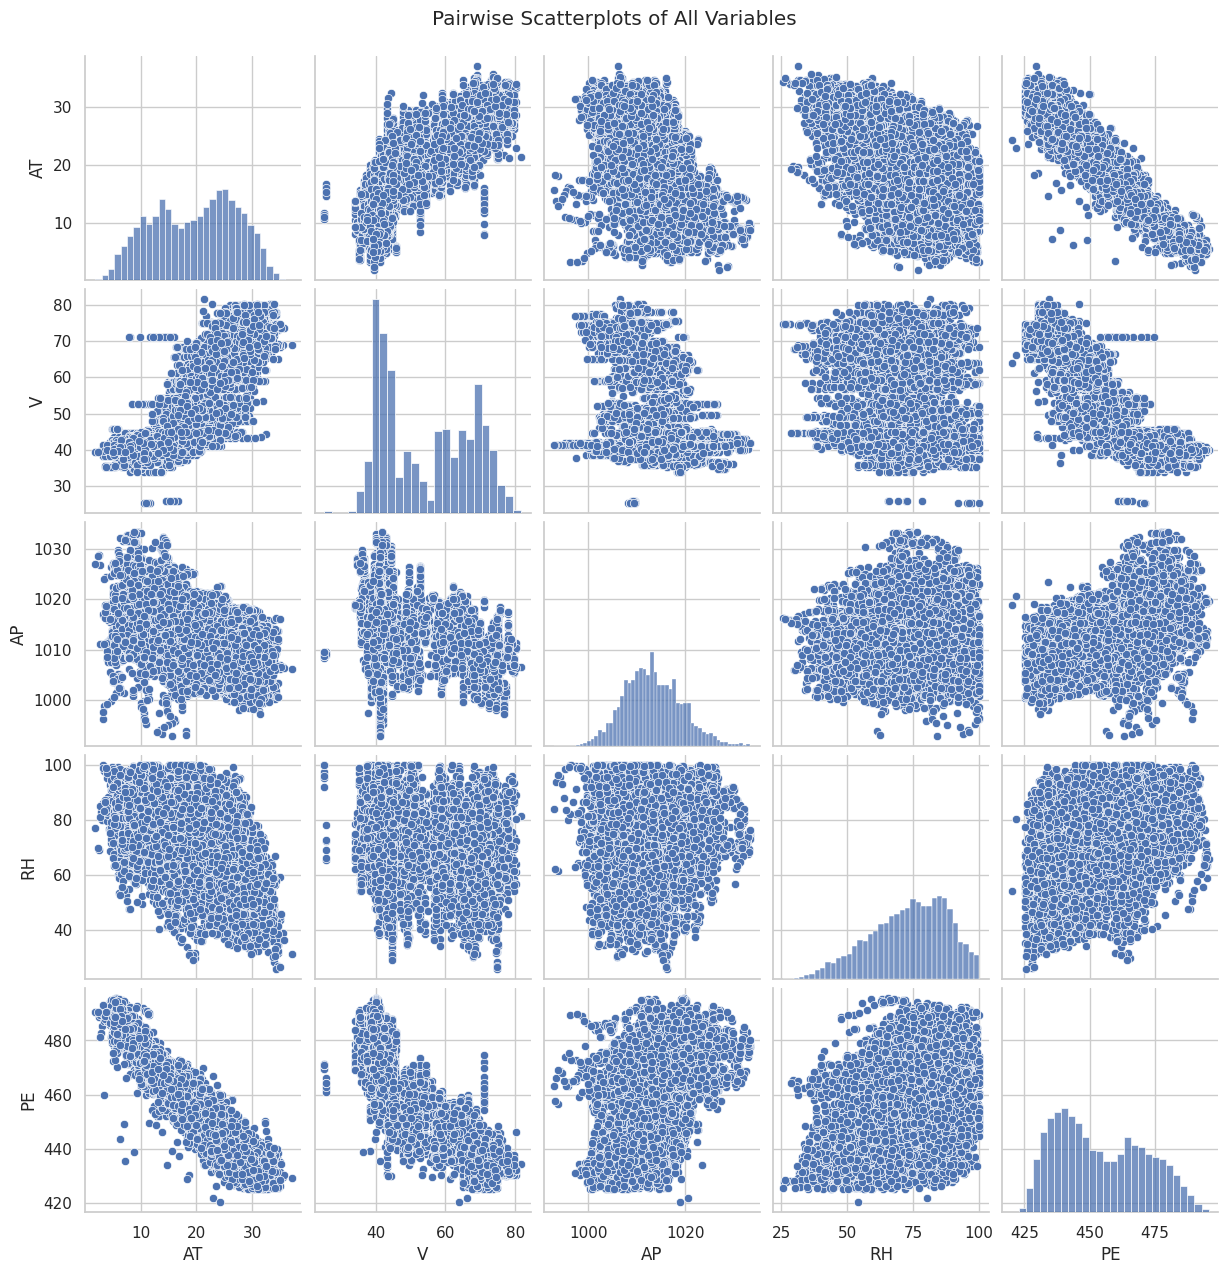

Summary Statistics Table:
           Mean    Median  Range  1st Quartile  3rd Quartile      IQR
AT    19.651231    20.345  35.30       13.5100         25.72  12.2100
V     54.305804    52.080  56.20       41.7400         66.54  24.8000
AP  1013.259078  1012.940  40.41     1009.1000       1017.26   8.1600
RH    73.308978    74.975  74.60       63.3275         84.83  21.5025
PE   454.365009   451.550  75.50      439.7500        468.43  28.6800
------------------------------------------------------------
Predictor: AT
Coefficient (Slope): -2.1713
p-value: 0.0
R-squared: 0.8989
Potential outliers detected based on Cook's distance: 416
Predictor: V
Coefficient (Slope): -1.1681
p-value: 0.0
R-squared: 0.7565
Potential outliers detected based on Cook's distance: 423
Predictor: AP
Coefficient (Slope): 1.4899
p-value: 0.0
R-squared: 0.2688
Potential outliers detected based on Cook's distance: 300
Predictor: RH
Coefficient (Slope): 0.4557
p-value: 0.0
R-squared: 0.1519
Potential outliers detecte

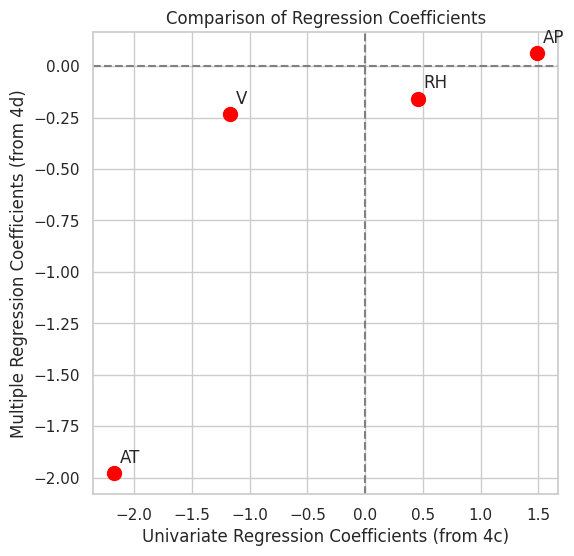

------------------------------------------------------------

===== Nonlinear Association Test (Cubic Fit) =====

Predictor: AT
  Squared term (X^2) p-value: 8.8330e-73
  Cubic term (X^3) p-value: 3.6522e-110

Predictor: V
  Squared term (X^2) p-value: 7.6850e-01
  Cubic term (X^3) p-value: 1.3735e-02

Predictor: AP
  Squared term (X^2) p-value: 3.6667e-17
  Cubic term (X^3) p-value: 8.2641e-18

Predictor: RH
  Squared term (X^2) p-value: 9.3954e-06
  Cubic term (X^3) p-value: 1.4403e-05
------------------------------------------------------------
Full Interaction Model Summary
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:               

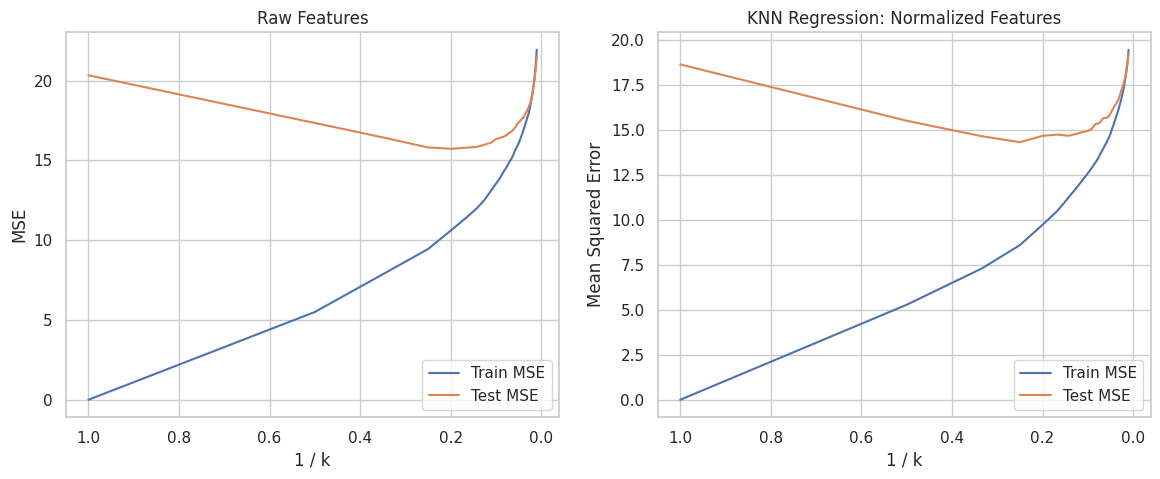

------------------------------------------------------------
j) Final Performance Summary
1. Base Multiple Linear Regression Test MSE:          21.2399
2. Improved Polynomial Linear Regression Test MSE:    19.2210
3. Best KNN Regression (Raw Features) Test MSE:       15.7268 (K=5)
4. Best KNN Regression (Normalized Features) Test MSE:14.3057 (K=4)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")
# (b) Data Exploration
df = pd.read_excel('/content/drive/MyDrive/data/Folds5x2_pp.xlsx', sheet_name='Sheet1')

# i. Dimensions
rows, cols = df.shape
print(f"Dataset has {rows} rows and {cols} columns.\n")

# ii. Scatterplots
sns.pairplot(df)
plt.suptitle("Pairwise Scatterplots of All Variables", y=1.02)
plt.show()

# iii. Summary statistics table
summary_table = df.describe().T
summary_table['range'] = summary_table['max'] - summary_table['min']
summary_table['IQR'] = summary_table['75%'] - summary_table['25%']
summary_table = summary_table[['mean', '50%', 'range', '25%', '75%', 'IQR']]
summary_table.columns = ['Mean', 'Median', 'Range', '1st Quartile', '3rd Quartile', 'IQR']
print("Summary Statistics Table:")
print(summary_table.to_string())
print("-" * 60)

# (c) Simple Linear Regression
predictors = ['AT', 'V', 'AP', 'RH']
univariate_coefs = {}

for p in predictors:
    X_p = sm.add_constant(df[p])
    y = df['PE']
    model = sm.OLS(y, X_p).fit()
    univariate_coefs[p] = model.params[p]

    print(f"Predictor: {p}")
    print(f"Coefficient (Slope): {model.params[p]:.4f}")
    print(f"p-value: {model.pvalues[p]}")
    print(f"R-squared: {model.rsquared:.4f}")

    # Outliers identification using Cook's distance
    influence = model.get_influence()
    cooks = influence.cooks_distance[0]
    outliers = np.where(cooks > 4 / len(df))[0]
    print(f"Potential outliers detected based on Cook's distance: {len(outliers)}")

print("-" * 60)


# (d) Multiple Linear Regression
X_multi = sm.add_constant(df[predictors])
y = df['PE']
multi_model = sm.OLS(y, X_multi).fit()
print("\Multiple Linear Regression Summary")
print(multi_model.summary())

multi_coefs = {p: multi_model.params[p] for p in predictors}
print("-" * 60)


# (e) Univariate vs Multiple Coefficients Plot
x_vals = [univariate_coefs[p] for p in predictors]
y_vals = [multi_coefs[p] for p in predictors]

plt.figure(figsize=(6, 6))
plt.scatter(x_vals, y_vals, color='red', s=100)
for i, p in enumerate(predictors):
    plt.text(x_vals[i] + 0.05, y_vals[i] + 0.05, p, fontsize=12)

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel("Univariate Regression Coefficients (from 4c)")
plt.ylabel("Multiple Regression Coefficients (from 4d)")
plt.title("Comparison of Regression Coefficients")
plt.grid(True)
plt.show()
print("-" * 60)


# (f) Nonlinear Association (Cubic Regression)
print("Nonlinear Association Test (Cubic Fit)")
for p in predictors:
    X_poly = pd.DataFrame({
        'X': df[p],
        'X2': df[p]**2,
        'X3': df[p]**3
    })
    X_poly = sm.add_constant(X_poly)
    poly_model = sm.OLS(df['PE'], X_poly).fit()

    print(f"\nPredictor: {p}")
    print(f"  Squared term (X^2) p-value: {poly_model.pvalues['X2']:.4e}")
    print(f"  Cubic term (X^3) p-value: {poly_model.pvalues['X3']:.4e}")
print("-" * 60)


# (g) Full Interaction Model
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter_raw = poly_inter.fit_transform(df[predictors])
inter_cols = poly_inter.get_feature_names_out(predictors)
X_inter_df = pd.DataFrame(X_inter_raw, columns=inter_cols)
X_inter_sm = sm.add_constant(X_inter_df)

inter_model = sm.OLS(df['PE'], X_inter_sm).fit()
print("Full Interaction Model Summary")
print(inter_model.summary())
print("-" * 60)


# (h) Model Improvement and Feature Selection
X_train_raw, X_test_raw, y_train, y_test = train_test_split(df[predictors], df['PE'], test_size=0.3, random_state=42)

# Model 1: Base Multiple Linear Regression
lr_base = LinearRegression()
lr_base.fit(X_train_raw, y_train)
train_mse_base = mean_squared_error(y_train, lr_base.predict(X_train_raw))
test_mse_base = mean_squared_error(y_test, lr_base.predict(X_test_raw))

print("Model 1: Base Multiple Regression")
print(f"  Train MSE: {train_mse_base:.4f}")
print(f"  Test MSE:  {test_mse_base:.4f}")

# Model 2: Interaction + Quadratic with p-value selection
poly_full = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = pd.DataFrame(poly_full.fit_transform(X_train_raw), columns=poly_full.get_feature_names_out(predictors))
X_test_poly = pd.DataFrame(poly_full.transform(X_test_raw), columns=poly_full.get_feature_names_out(predictors))

X_train_poly_sm = sm.add_constant(X_train_poly)
improvement_model = sm.OLS(y_train.values, X_train_poly_sm).fit()

significant_features = improvement_model.pvalues[improvement_model.pvalues < 0.05].index.tolist()
if 'const' in significant_features:
    significant_features.remove('const')

X_train_select = X_train_poly[significant_features]
X_test_select = X_test_poly[significant_features]

lr_improved = LinearRegression()
lr_improved.fit(X_train_select, y_train)

train_mse_improved = mean_squared_error(y_train, lr_improved.predict(X_train_select))
test_mse_improved = mean_squared_error(y_test, lr_improved.predict(X_test_select))

print("Model 2: Improved Model (Selected Interaction & Quadratic Terms)")
print(f"  Selected Features: {significant_features}")
print(f"  Train MSE: {train_mse_improved:.4f}")
print(f"  Test MSE:  {test_mse_improved:.4f}")
print("-" * 60)


# (i) KNN Regression
k_range = range(1, 101)
raw_train_errors, raw_test_errors = [], []
norm_train_errors, norm_test_errors = [], []

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

for k in k_range:
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train_raw, y_train)
    raw_train_errors.append(mean_squared_error(y_train, knn_raw.predict(X_train_raw)))
    raw_test_errors.append(mean_squared_error(y_test, knn_raw.predict(X_test_raw)))

    knn_norm = KNeighborsRegressor(n_neighbors=k)
    knn_norm.fit(X_train_norm, y_train)
    norm_train_errors.append(mean_squared_error(y_train, knn_norm.predict(X_train_norm)))
    norm_test_errors.append(mean_squared_error(y_test, knn_norm.predict(X_test_norm)))

inv_k = [1 / k for k in k_range]
best_k_raw = k_range[np.argmin(raw_test_errors)]
best_mse_raw = min(raw_test_errors)
best_k_norm = k_range[np.argmin(norm_test_errors)]
best_mse_norm = min(norm_test_errors)

print("KNN Regression Results")
print(f"Raw Features:        Best K = {best_k_raw}, Min Test MSE = {best_mse_raw:.4f}")
print(f"Normalized Features: Best K = {best_k_norm}, Min Test MSE = {best_mse_norm:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw Features
ax1.plot(inv_k, raw_train_errors, label='Train MSE')
ax1.plot(inv_k, raw_test_errors, label='Test MSE')
ax1.set_xlabel('1 / k')
ax1.set_ylabel('MSE')
ax1.set_title('Raw Features')
ax1.invert_xaxis()
ax1.legend()

# Plot 2: Normalized Features
ax2.plot(inv_k, norm_train_errors, label='Train MSE')
ax2.plot(inv_k, norm_test_errors, label='Test MSE')
ax2.set_xlabel('1 / k')
ax2.set_ylabel('Mean Squared Error')
ax2.set_title('KNN Regression: Normalized Features')
ax2.invert_xaxis()
ax2.legend()

plt.show()
print("-" * 60)


# (j) Final Model Comparison
print("j) Final Performance Summary")
print(f"1. Base Multiple Linear Regression Test MSE:          {test_mse_base:.4f}")
print(f"2. Improved Polynomial Linear Regression Test MSE:    {test_mse_improved:.4f}")
print(f"3. Best KNN Regression (Raw Features) Test MSE:       {best_mse_raw:.4f} (K={best_k_raw})")
print(f"4. Best KNN Regression (Normalized Features) Test MSE:{best_mse_norm:.4f} (K={best_k_norm})")